<a href="https://colab.research.google.com/github/Santiago-Soria/proyecto-transformacion-texto-imagen/blob/main/notebooks/2_run_experimentos_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Santiago-Soria/proyecto-transformacion-texto-imagen.git
# ==========================================
# CELDA 1: Setup
# ==========================================
import sys, os

PROJECT_ROOT = '/content/proyecto-transformacion-texto-imagen'
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))

!pip install -q transformers torch scikit-learn polars joblib

from transformers import logging as hf_logging
import warnings
hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore")

print("✓ Entorno listo")


Cloning into 'proyecto-transformacion-texto-imagen'...
remote: Enumerating objects: 331, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 331 (delta 18), reused 9 (delta 2), pack-reused 296 (from 1)
Receiving objects: 100% (331/331), 6.14 MiB | 9.69 MiB/s, done.
Resolving deltas: 100% (168/168), done.
✓ Entorno listo


In [2]:
# ==========================================
# CELDA 2: Carga de datos con los 3 splits
# ==========================================
import polars as pl
import numpy as np

ruta = f'{PROJECT_ROOT}/data/processed'

train_df = pl.read_csv(f'{ruta}/train.csv')
val_df   = pl.read_csv(f'{ruta}/validation.csv')
test_df  = pl.read_csv(f'{ruta}/test.csv')

X_train = train_df.get_column('text').to_list()
y_train = train_df.get_column('manual_classification').to_numpy()

X_val   = val_df.get_column('text').to_list()
y_val   = val_df.get_column('manual_classification').to_numpy()

X_test  = test_df.get_column('text').to_list()
y_test  = test_df.get_column('manual_classification').to_numpy()

print(f"✓ Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"  Train → Dep: {y_train.sum()} | No Dep: {(y_train==0).sum()}")
print(f"  Val   → Dep: {y_val.sum()}   | No Dep: {(y_val==0).sum()}")
print(f"  Test  → Dep: {y_test.sum()}  | No Dep: {(y_test==0).sum()}")


✓ Train: 908 | Val: 114 | Test: 114
  Train → Dep: 353 | No Dep: 555
  Val   → Dep: 44   | No Dep: 70
  Test  → Dep: 44  | No Dep: 70


In [3]:
# ==========================================
# CELDA 3: Funciones de utilidad corregidas
# ==========================================
from src.features.extraction import *
from src.models.train_classic import *
from src.models.train_transformer import *
from src.preprocessing_utils import *

print("✓ Funciones de utilidad cargadas")


✓ Funciones de utilidad cargadas


EXP 1.1: Limpieza Básica + TF-IDF + LogReg

Entrenando Regresión Logística para: Exp_1.1_TFIDF_LogReg

  Exp_1.1_TFIDF_LogReg
  Val  F1-Macro:  0.7137
  Test Accuracy:  0.7018
  Test Precision: 0.6867
  Test Recall:    0.6896
  Test F1-Macro:  0.6879  ← métrica principal

              precision    recall  f1-score   support

      No Dep       0.76      0.74      0.75        70
         Dep       0.61      0.64      0.62        44

    accuracy                           0.70       114
   macro avg       0.69      0.69      0.69       114
weighted avg       0.70      0.70      0.70       114


Confusion Matrix:


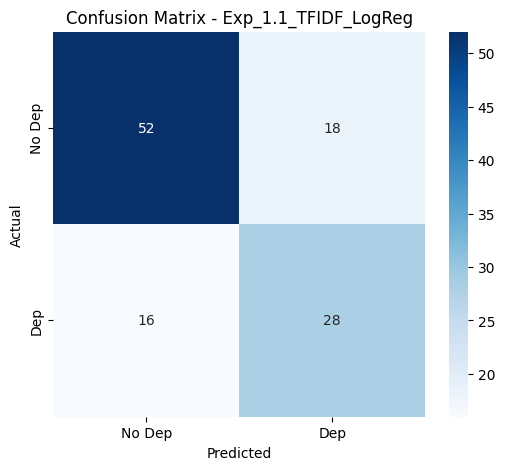

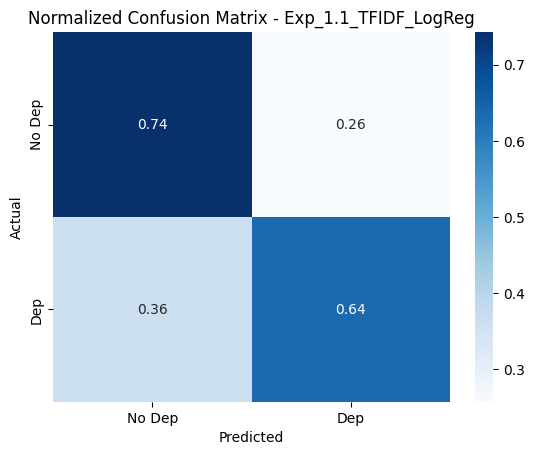


Modelo guardado en: /content/proyecto-transformacion-texto-imagen/models/Exp_1.1_TFIDF_LogReg.pkl
Métricas guardadas en: /content/proyecto-transformacion-texto-imagen/models/../results/Exp_1.1_TFIDF_LogReg_metrics.json

EXP 1.2: Limpieza Básica + Stopwords + TF-IDF + LogReg

Entrenando Regresión Logística para: Exp_1.2_TFIDF_Stopwords_LogReg

  Exp_1.2_TFIDF_Stopwords_LogReg
  Val  F1-Macro:  0.6742
  Test Accuracy:  0.7105
  Test Precision: 0.6984
  Test Recall:    0.7052
  Test F1-Macro:  0.7004  ← métrica principal

              precision    recall  f1-score   support

      No Dep       0.78      0.73      0.76        70
         Dep       0.61      0.68      0.65        44

    accuracy                           0.71       114
   macro avg       0.70      0.71      0.70       114
weighted avg       0.72      0.71      0.71       114


Confusion Matrix:


<Figure size 640x480 with 0 Axes>

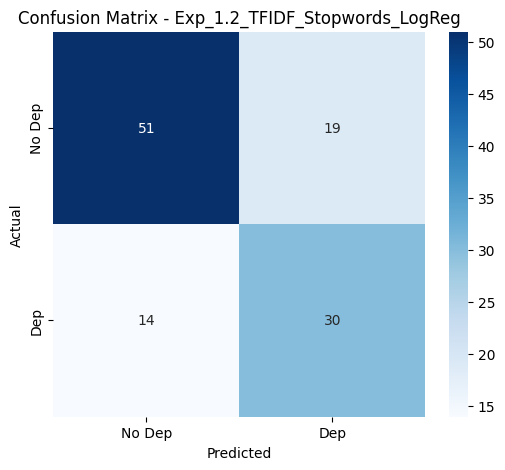

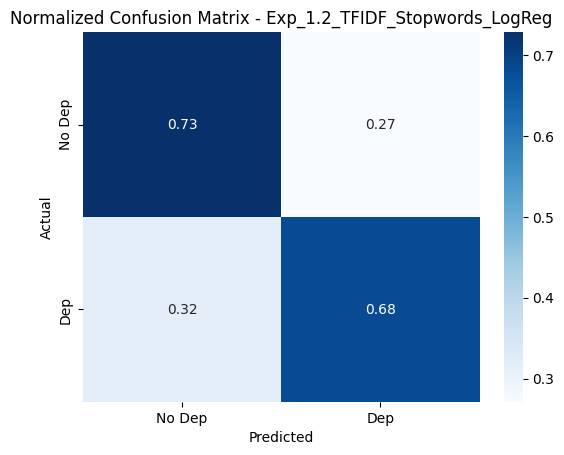


Modelo guardado en: /content/proyecto-transformacion-texto-imagen/models/Exp_1.2_TFIDF_Stopwords_LogReg.pkl
Métricas guardadas en: /content/proyecto-transformacion-texto-imagen/models/../results/Exp_1.2_TFIDF_Stopwords_LogReg_metrics.json

✓ Experimentos 1.x completados


<Figure size 640x480 with 0 Axes>

In [5]:
# ==========================================
# CELDA 4: Experimentos 1.1 y 1.2 — TF-IDF
# ==========================================
import joblib
import os
extractor = FeatureExtractor()

# Define the models directory
models_dir = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(models_dir, exist_ok=True)

# ── Exp 1.1: Limpieza básica + TF-IDF ──────────────────────
print("EXP 1.1: Limpieza Básica + TF-IDF + LogReg")
X_train_clean = [preprocess_text(t, 'P1') for t in X_train]
X_val_clean   = [preprocess_text(t, 'P1') for t in X_val]
X_test_clean  = [preprocess_text(t, 'P1') for t in X_test]

X_tr_11, X_val_11, X_te_11, vec_11 = extractor.get_tfidf(
    X_train_clean, X_val_clean, X_test_clean)

_, _, metrics_11 = train_logistic(
    X_tr_11, y_train, X_val_11, y_val,
    X_te_11, y_test, 'Exp_1.1_TFIDF_LogReg', models_dir=models_dir)

# ── Exp 1.2: Limpieza básica + Stopwords + TF-IDF ──────────
print("\nEXP 1.2: Limpieza Básica + Stopwords + TF-IDF + LogReg")

X_train_sw = [preprocess_text(t, 'P2') for t in X_train]
X_val_sw   = [preprocess_text(t, 'P2') for t in X_val]
X_test_sw  = [preprocess_text(t, 'P2') for t in X_test]

X_tr_12, X_val_12, X_te_12, vec_12 = extractor.get_tfidf(
    X_train_sw, X_val_sw, X_test_sw)

_, _, metrics_12 = train_logistic(
    X_tr_12, y_train, X_val_12, y_val,
    X_te_12, y_test, 'Exp_1.2_TFIDF_Stopwords_LogReg', models_dir=models_dir)

print("\n✓ Experimentos 1.x completados")

EXP 2.1: BETO Frozen + LogReg
  Extrayendo embeddings (train)...
--> Extrayendo embeddings con dccuchile/bert-base-spanish-wwm-cased...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

100%|██████████| 29/29 [00:07<00:00,  4.08it/s]


  Extrayendo embeddings (val)...
--> Extrayendo embeddings con dccuchile/bert-base-spanish-wwm-cased...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00,  4.25it/s]


  Extrayendo embeddings (test)...
--> Extrayendo embeddings con dccuchile/bert-base-spanish-wwm-cased...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00,  4.27it/s]



Entrenando Regresión Logística para: Exp_2.1_BETO_Frozen_LogReg

  Exp_2.1_BETO_Frozen_LogReg
  Val  F1-Macro:  0.6038
  Test Accuracy:  0.7281
  Test Precision: 0.7147
  Test Recall:    0.7195
  Test F1-Macro:  0.7165  ← métrica principal

              precision    recall  f1-score   support

      No Dep       0.79      0.76      0.77        70
         Dep       0.64      0.68      0.66        44

    accuracy                           0.73       114
   macro avg       0.71      0.72      0.72       114
weighted avg       0.73      0.73      0.73       114


Confusion Matrix:


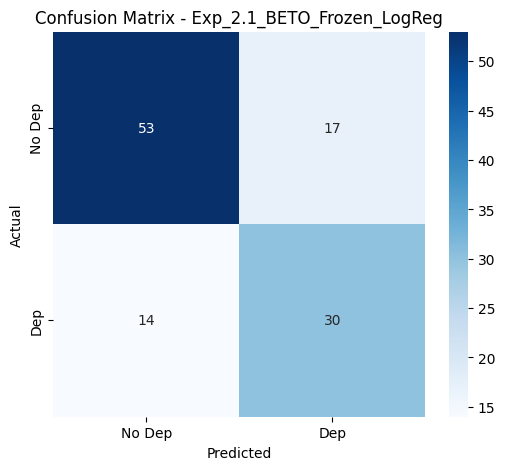

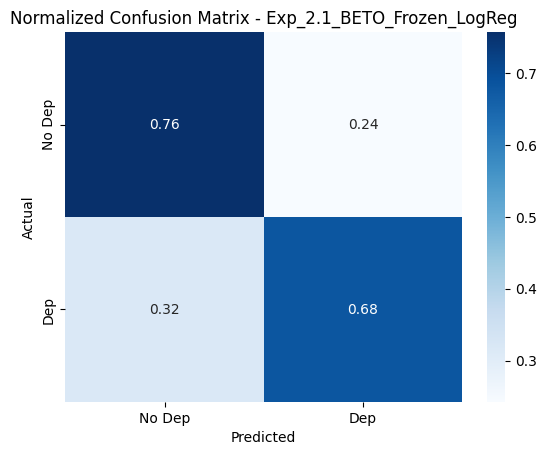


Modelo guardado en: /content/proyecto-transformacion-texto-imagen/models/Exp_2.1_BETO_Frozen_LogReg.pkl
Métricas guardadas en: /content/proyecto-transformacion-texto-imagen/models/../results/Exp_2.1_BETO_Frozen_LogReg_metrics.json
EXP 2.2: RoBERTa Frozen + LogReg
  Extrayendo embeddings (train)...
--> Extrayendo embeddings con bertin-project/bertin-roberta-base-spanish...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

100%|██████████| 29/29 [00:06<00:00,  4.18it/s]


  Extrayendo embeddings (val)...
--> Extrayendo embeddings con bertin-project/bertin-roberta-base-spanish...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

  Extrayendo embeddings (test)...
--> Extrayendo embeddings con bertin-project/bertin-roberta-base-spanish...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:01<00:00,  3.98it/s]



Entrenando Regresión Logística para: Exp_2.2_RoBERTa_Frozen_LogReg

  Exp_2.2_RoBERTa_Frozen_LogReg
  Val  F1-Macro:  0.6402
  Test Accuracy:  0.6228
  Test Precision: 0.6089
  Test Recall:    0.6127
  Test F1-Macro:  0.6096  ← métrica principal

              precision    recall  f1-score   support

      No Dep       0.71      0.66      0.68        70
         Dep       0.51      0.57      0.54        44

    accuracy                           0.62       114
   macro avg       0.61      0.61      0.61       114
weighted avg       0.63      0.62      0.63       114


Confusion Matrix:


<Figure size 640x480 with 0 Axes>

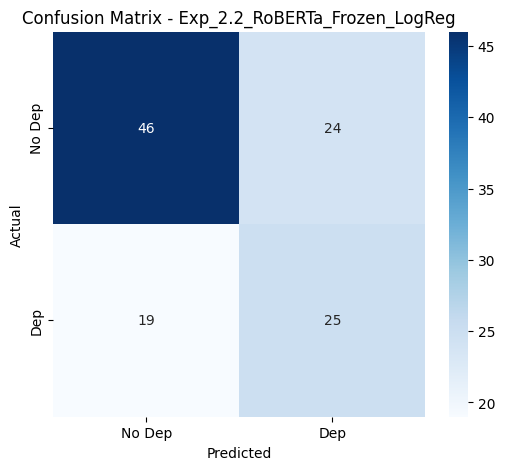

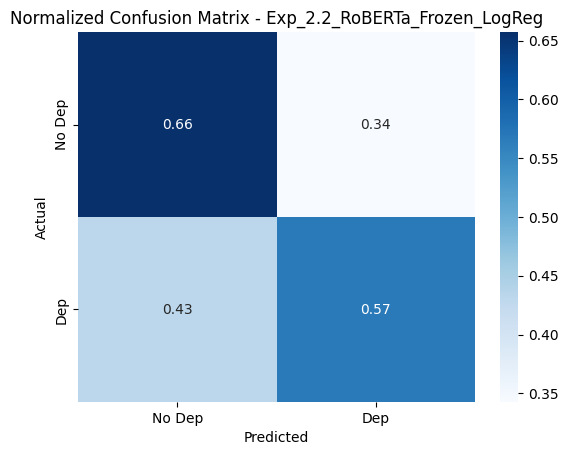


Modelo guardado en: /content/proyecto-transformacion-texto-imagen/models/Exp_2.2_RoBERTa_Frozen_LogReg.pkl
Métricas guardadas en: /content/proyecto-transformacion-texto-imagen/models/../results/Exp_2.2_RoBERTa_Frozen_LogReg_metrics.json

EXP 2.3: mDeBERTa Frozen + LogReg
  Extrayendo embeddings (train)...
--> Extrayendo embeddings con microsoft/mdeberta-v3-base...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

100%|██████████| 29/29 [00:03<00:00,  8.04it/s]


  Extrayendo embeddings (val)...
--> Extrayendo embeddings con microsoft/mdeberta-v3-base...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

...

  Extrayendo embeddings (test)...
--> Extrayendo embeddings con microsoft/mdeberta-v3-base...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00,  6.87it/s]



Entrenando Regresión Logística para: Exp_2.3_mDeBERTa_Frozen_LogReg

  Exp_2.3_mDeBERTa_Frozen_LogReg
  Val  F1-Macro:  0.5885
  Test Accuracy:  0.5526
  Test Precision: 0.5262
  Test Recall:    0.5260
  Test F1-Macro:  0.5260  ← métrica principal

              precision    recall  f1-score   support

      No Dep       0.63      0.64      0.64        70
         Dep       0.42      0.41      0.41        44

    accuracy                           0.55       114
   macro avg       0.53      0.53      0.53       114
weighted avg       0.55      0.55      0.55       114


Confusion Matrix:


<Figure size 640x480 with 0 Axes>

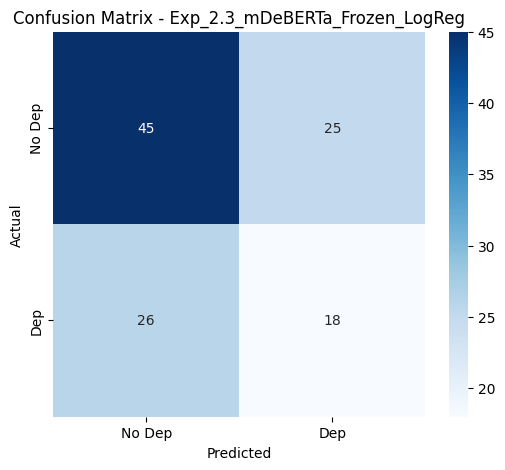

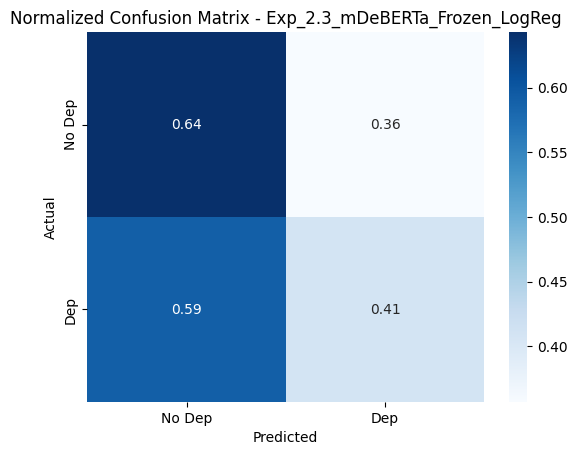


Modelo guardado en: /content/proyecto-transformacion-texto-imagen/models/Exp_2.3_mDeBERTa_Frozen_LogReg.pkl
Métricas guardadas en: /content/proyecto-transformacion-texto-imagen/models/../results/Exp_2.3_mDeBERTa_Frozen_LogReg_metrics.json

EXP 2.4: XLM-RoBERTa Frozen + LogReg
  Extrayendo embeddings (train)...
--> Extrayendo embeddings con xlm-roberta-base...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 29/29 [00:06<00:00,  4.26it/s]


  Extrayendo embeddings (val)...
--> Extrayendo embeddings con xlm-roberta-base...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

  Extrayendo embeddings (test)...
--> Extrayendo embeddings con xlm-roberta-base...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00,  4.04it/s]



Entrenando Regresión Logística para: Exp_2.4_XLM_Frozen_LogReg

  Exp_2.4_XLM_Frozen_LogReg
  Val  F1-Macro:  0.6923
  Test Accuracy:  0.6842
  Test Precision: 0.6685
  Test Recall:    0.6711
  Test F1-Macro:  0.6696  ← métrica principal

              precision    recall  f1-score   support

      No Dep       0.75      0.73      0.74        70
         Dep       0.59      0.61      0.60        44

    accuracy                           0.68       114
   macro avg       0.67      0.67      0.67       114
weighted avg       0.69      0.68      0.69       114


Confusion Matrix:


<Figure size 640x480 with 0 Axes>

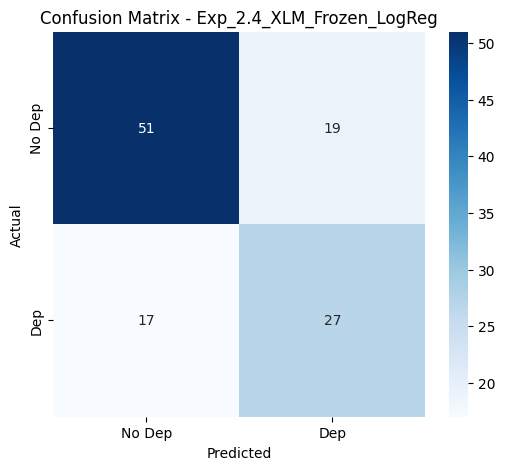

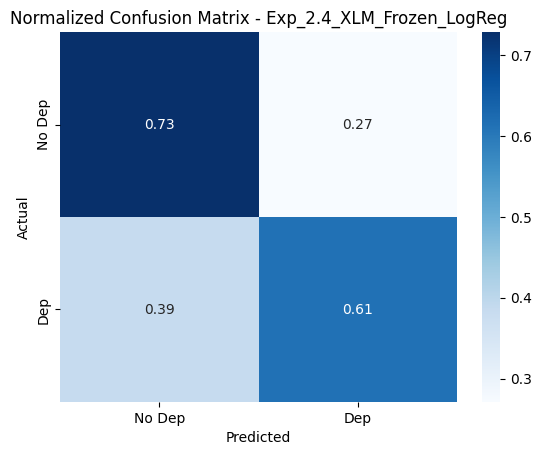


Modelo guardado en: /content/proyecto-transformacion-texto-imagen/models/Exp_2.4_XLM_Frozen_LogReg.pkl
Métricas guardadas en: /content/proyecto-transformacion-texto-imagen/models/../results/Exp_2.4_XLM_Frozen_LogReg_metrics.json

✓ Experimentos 2.x completados


<Figure size 640x480 with 0 Axes>

In [19]:
# ===============================================
# CELDA 5: Experimentos 2.1, 2.2, 2.3 y 2.4 — Frozen
# ===============================================

# ── Exp 2.1: RoBERTa Frozen ────────────────────────────────
print("EXP 2.1: BETO Frozen + LogReg")
BETO = "dccuchile/bert-base-spanish-wwm-cased"

print("  Extrayendo embeddings (train)...")
X_tr_21  = extractor.get_frozen_embeddings(X_train_clean, BETO)
print("  Extrayendo embeddings (val)...")
X_val_21 = extractor.get_frozen_embeddings(X_val_clean,   BETO)
print("  Extrayendo embeddings (test)...")
X_te_21  = extractor.get_frozen_embeddings(X_test_clean,  BETO)

_, _, metrics_21 = train_logistic(
    X_tr_21, y_train, X_val_21, y_val,
    X_te_21, y_test, 'Exp_2.1_BETO_Frozen_LogReg', models_dir=models_dir)

# ── Exp 2.2: RoBERTa Frozen ────────────────────────────────
print("EXP 2.2: RoBERTa Frozen + LogReg")
ROBERTA = 'bertin-project/bertin-roberta-base-spanish'

print("  Extrayendo embeddings (train)...")
X_tr_22  = extractor.get_frozen_embeddings(X_train_clean, ROBERTA)
print("  Extrayendo embeddings (val)...")
X_val_22 = extractor.get_frozen_embeddings(X_val_clean,   ROBERTA)
print("  Extrayendo embeddings (test)...")
X_te_22  = extractor.get_frozen_embeddings(X_test_clean,  ROBERTA)

_, _, metrics_22 = train_logistic(
    X_tr_22, y_train, X_val_22, y_val,
    X_te_22, y_test, 'Exp_2.2_RoBERTa_Frozen_LogReg', models_dir=models_dir)

# ── Exp 2.3: mDeBERTa Frozen ───────────────────────────────
print("\nEXP 2.3: mDeBERTa Frozen + LogReg")
MDEBERTA = 'microsoft/mdeberta-v3-base'

print("  Extrayendo embeddings (train)...")
X_tr_23  = extractor.get_frozen_embeddings(X_train_clean, MDEBERTA)
print("  Extrayendo embeddings (val)...")
X_val_23 = extractor.get_frozen_embeddings(X_val_clean,   MDEBERTA)
print("  Extrayendo embeddings (test)...")
X_te_23  = extractor.get_frozen_embeddings(X_test_clean,  MDEBERTA)

_, _, metrics_23 = train_logistic(
    X_tr_23, y_train, X_val_23, y_val,
    X_te_23, y_test, 'Exp_2.3_mDeBERTa_Frozen_LogReg', models_dir=models_dir)

# ── Exp 2.4: XLM-RoBERTa Frozen ───────────────────────────────
print("\nEXP 2.4: XLM-RoBERTa Frozen + LogReg")
XLM = "xlm-roberta-base"

print("  Extrayendo embeddings (train)...")
X_tr_24  = extractor.get_frozen_embeddings(X_train_clean, XLM)
print("  Extrayendo embeddings (val)...")
X_val_24 = extractor.get_frozen_embeddings(X_val_clean,   XLM)
print("  Extrayendo embeddings (test)...")
X_te_24  = extractor.get_frozen_embeddings(X_test_clean,  XLM)

_, _, metrics_24 = train_logistic(
    X_tr_24, y_train, X_val_24, y_val,
    X_te_24, y_test, 'Exp_2.4_XLM_Frozen_LogReg', models_dir=models_dir)


print("\n✓ Experimentos 2.x completados")


In [12]:
import os
import json
import torch
import numpy as np
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Reproducibilidad
# ==============================
set_seed(42)


# ==============================
# Dataset
# ==============================
class DepressionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )

        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


# ==============================
# Métricas
# ==============================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
    }


# ==============================
# Fine-Tuning Principal
# ==============================
def run_finetuning(train_texts, train_labels, val_texts, val_labels, model_name, models_dir):

    model_path = os.path.join(models_dir, f"{model_name}.pkl")
    results_dir = os.path.join(models_dir, "..", "results")
    os.makedirs(results_dir, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    train_ds = DepressionDataset(train_texts, train_labels, tokenizer)
    val_ds = DepressionDataset(val_texts, val_labels, tokenizer)

    safe_model_name = model_name.replace("/", "_")
    output_dir = f"models/checkpoints/{safe_model_name}"

    training_args = TrainingArguments(
        output_dir=output_dir,

        # Estrategia de evaluación
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",

        # Optimización
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=6,
        weight_decay=0.01,

        # Selección del mejor modelo
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,

        # Control de checkpoints
        save_total_limit=1,

        # Reproducibilidad
        seed=42,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    # ==========================
    # Evaluación Final
    # ==========================
    final_metrics = trainer.evaluate()
    print("\nFinal Evaluation Metrics:")
    print(final_metrics)

    # Guardar métricas en JSON
    os.makedirs("results", exist_ok=True)
    with open(f"results/{safe_model_name}_metrics.json", "w") as f:
        json.dump(final_metrics, f, indent=4)

    return trainer

In [10]:
def extraer_embeddings_finetuned(texts, ckpt_path, batch_size=16):
    """
    Extrae embeddings [CLS] del BETO fine-tuneado.
    Usa AutoModel (sin cabeza de clasificación) para obtener representaciones puras.
    """
    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained(ckpt_path)

    # AutoModel carga SOLO el encoder, sin la capa de clasificación
    model     = AutoModel.from_pretrained(ckpt_path).to(device)
    model.eval()

    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Extrayendo embeddings"):
        batch  = texts[i:i + batch_size]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            outputs    = model(**inputs)
            cls_emb    = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(cls_emb)

    return np.vstack(all_embeddings)


In [13]:
# ==========================================
# CELDA 6: Experimentos 3.1, 3.2, 3.3 y 3.4 — Fine-tuning
# ==========================================

# ── Exp 3.1: BETO Fine-Tuning ───────────────────────────
print("="*55)
print("EXP 3.1: BETO Fine-Tuning + Softmax")
print("  Train → val.csv (EarlyStopping) | Eval final → test.csv")
print("="*55)

trainer_31 = run_finetuning(
    X_train_clean, y_train,   # ← train para aprender pesos
    X_val_clean,   y_val,     # ← val para EarlyStopping (NO test)
    model_name=BETO,
    models_dir=models_dir
)


EXP 3.1: BETO Fine-Tuning + Softmax
  Train → val.csv (EarlyStopping) | Eval final → test.csv


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

{'loss': '0.6391', 'grad_norm': '11.44', 'learning_rate': '1.673e-05', 'epoch': '1'}
{'eval_loss': '0.5804', 'eval_accuracy': '0.6754', 'eval_precision_macro': '0.6557', 'eval_recall_macro': '0.6513', 'eval_f1_macro': '0.653', 'eval_runtime': '1.038', 'eval_samples_per_second': '109.9', 'eval_steps_per_second': '7.711', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.5023', 'grad_norm': '18.45', 'learning_rate': '1.339e-05', 'epoch': '2'}
{'eval_loss': '0.6336', 'eval_accuracy': '0.6491', 'eval_precision_macro': '0.625', 'eval_recall_macro': '0.5877', 'eval_f1_macro': '0.5809', 'eval_runtime': '1.021', 'eval_samples_per_second': '111.7', 'eval_steps_per_second': '7.838', 'epoch': '2'}


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1189', 'grad_norm': '19.14', 'learning_rate': '3.392e-06', 'epoch': '5'}
{'eval_loss': '1.082', 'eval_accuracy': '0.6491', 'eval_precision_macro': '0.6239', 'eval_recall_macro': '0.613', 'eval_f1_macro': '0.6149', 'eval_runtime': '1.023', 'eval_samples_per_second': '111.5', 'eval_steps_per_second': '7.823', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '406.9', 'train_samples_per_second': '13.39', 'train_steps_per_second': '0.841', 'train_loss': '0.3754', 'epoch': '5'}
{'eval_loss': '0.6919', 'eval_accuracy': '0.693', 'eval_precision_macro': '0.683', 'eval_recall_macro': '0.6909', 'eval_f1_macro': '0.6842', 'eval_runtime': '1.038', 'eval_samples_per_second': '109.9', 'eval_steps_per_second': '7.71', 'epoch': '5'}

Final Evaluation Metrics:
{'eval_loss': 0.6919025778770447, 'eval_accuracy': 0.6929824561403509, 'eval_precision_macro': 0.6830065359477124, 'eval_recall_macro': 0.6909090909090909, 'eval_f1_macro': 0.6842105263157894, 'eval_runtime': 1.0376, 'eval_samples_per_second': 109.87, 'eval_steps_per_second': 7.71, 'epoch': 5.0}


OSError: Error no file named model.safetensors, or pytorch_model.bin, found in directory /content/proyecto-transformacion-texto-imagen/models/checkpoints/dccuchile_bert-base-spanish-wwm-cased.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Extrayendo embeddings: 100%|██████████| 57/57 [00:08<00:00,  6.71it/s]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Extrayendo embeddings: 100%|██████████| 8/8 [00:01<00:00,  6.87it/s]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Extrayendo embeddings: 100%|██████████| 8/8 [00:01<00:00,  6.91it/s]



Entrenando Regresión Logística para: Exp_3.1_RoBERTa_FineTuning

  Exp_3.1_RoBERTa_FineTuning
  Val  F1-Macro:  0.6114
  Test Accuracy:  0.7544
  Test Precision: 0.7419
  Test Recall:    0.7325
  Test F1-Macro:  0.7361  ← métrica principal

              precision    recall  f1-score   support

      No Dep       0.78      0.83      0.81        70
         Dep       0.70      0.64      0.67        44

    accuracy                           0.75       114
   macro avg       0.74      0.73      0.74       114
weighted avg       0.75      0.75      0.75       114


Confusion Matrix:


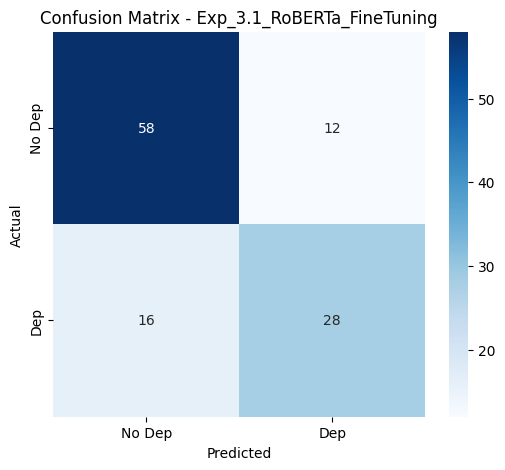

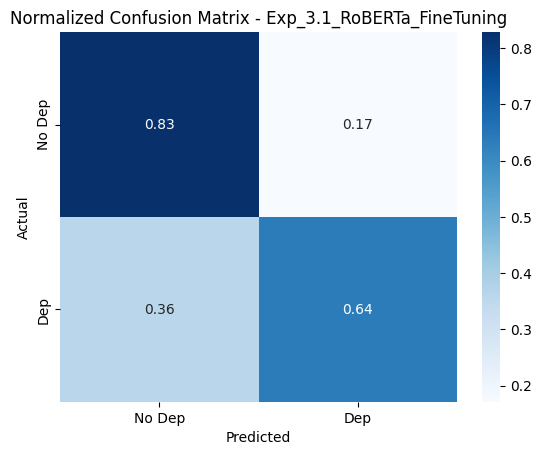


Modelo guardado en: /content/proyecto-transformacion-texto-imagen/models/Exp_3.1_RoBERTa_FineTuning.pkl
Métricas guardadas en: /content/proyecto-transformacion-texto-imagen/models/../results/Exp_3.1_RoBERTa_FineTuning_metrics.json


<Figure size 640x480 with 0 Axes>

In [15]:

# Extraer embeddings del modelo fine-tuneado para PKL
from transformers import AutoModelForSequenceClassification
CKPT_31 = f'{PROJECT_ROOT}/models/checkpoints/dccuchile_bert-base-spanish-wwm-cased/checkpoint-171'

# Guardar tokenizer en checkpoint
AutoTokenizer.from_pretrained(BETO).save_pretrained(CKPT_31)

X_tr_31  = extraer_embeddings_finetuned(X_train_clean, CKPT_31)
X_val_31 = extraer_embeddings_finetuned(X_val_clean,   CKPT_31)
X_te_31  = extraer_embeddings_finetuned(X_test_clean,  CKPT_31)

_, _, metrics_31 = train_logistic(
    X_tr_31, y_train, X_val_31, y_val,
    X_te_31, y_test, 'Exp_3.1_BETO_FineTuning', models_dir=models_dir)


In [16]:
# ── Exp 3.2: ROBERTA Fine-Tuning ───────────────────────────
print("="*55)
print("EXP 3.2: ROBERTA Fine-Tuning + Softmax")
print("  Train → val.csv (EarlyStopping) | Eval final → test.csv")
print("="*55)

trainer_32 = run_finetuning(
    X_train_clean, y_train,   # ← train para aprender pesos
    X_val_clean,   y_val,     # ← val para EarlyStopping (NO test)
    model_name=ROBERTA,
    models_dir=models_dir
)

EXP 3.2: ROBERTA Fine-Tuning + Softmax
  Train → val.csv (EarlyStopping) | Eval final → test.csv


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

{'loss': '0.6739', 'grad_norm': '3.786', 'learning_rate': '1.673e-05', 'epoch': '1'}
{'eval_loss': '0.6442', 'eval_accuracy': '0.6053', 'eval_precision_macro': '0.3053', 'eval_recall_macro': '0.4929', 'eval_f1_macro': '0.377', 'eval_runtime': '1.299', 'eval_samples_per_second': '87.78', 'eval_steps_per_second': '6.16', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.593', 'grad_norm': '8.324', 'learning_rate': '1.339e-05', 'epoch': '2'}
{'eval_loss': '0.5905', 'eval_accuracy': '0.6404', 'eval_precision_macro': '0.6196', 'eval_recall_macro': '0.6185', 'eval_f1_macro': '0.619', 'eval_runtime': '1.073', 'eval_samples_per_second': '106.2', 'eval_steps_per_second': '7.452', 'epoch': '2'}


...

{'loss': '0.1956', 'grad_norm': '20.22', 'learning_rate': '3.392e-06', 'epoch': '5'}
{'eval_loss': '0.8885', 'eval_accuracy': '0.6667', 'eval_precision_macro': '0.6579', 'eval_recall_macro': '0.6653', 'eval_f1_macro': '0.6581', 'eval_runtime': '0.983', 'eval_samples_per_second': '116', 'eval_steps_per_second': '8.138', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1176', 'grad_norm': '2.374', 'learning_rate': '5.848e-08', 'epoch': '6'}
{'eval_loss': '0.9342', 'eval_accuracy': '0.6842', 'eval_precision_macro': '0.6787', 'eval_recall_macro': '0.688', 'eval_f1_macro': '0.6779', 'eval_runtime': '1.014', 'eval_samples_per_second': '112.4', 'eval_steps_per_second': '7.886', 'epoch': '6'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '309', 'train_samples_per_second': '17.63', 'train_steps_per_second': '1.107', 'train_loss': '0.3934', 'epoch': '6'}
{'eval_loss': '0.6493', 'eval_accuracy': '0.7018', 'eval_precision_macro': '0.7038', 'eval_recall_macro': '0.7149', 'eval_f1_macro': '0.6984', 'eval_runtime': '1.065', 'eval_samples_per_second': '107', 'eval_steps_per_second': '7.51', 'epoch': '6'}

Final Evaluation Metrics:
{'eval_loss': 0.649337112903595, 'eval_accuracy': 0.7017543859649122, 'eval_precision_macro': 0.7038177339901477, 'eval_recall_macro': 0.714935064935065, 'eval_f1_macro': 0.6984126984126984, 'eval_runtime': 1.0653, 'eval_samples_per_second': 107.014, 'eval_steps_per_second': 7.51, 'epoch': 6.0}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Extrayendo embeddings: 100%|██████████| 57/57 [00:07<00:00,  7.68it/s]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Extrayendo embeddings: 100%|██████████| 8/8 [00:00<00:00,  8.35it/s]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Extrayendo embeddings: 100%|██████████| 8/8 [00:00<00:00,  8.11it/s]



Entrenando Regresión Logística para: Exp_3.2_RoBERTa_FineTuning

  Exp_3.2_RoBERTa_FineTuning
  Val  F1-Macro:  0.6941
  Test Accuracy:  0.6579
  Test Precision: 0.6401
  Test Recall:    0.6412
  Test F1-Macro:  0.6406  ← métrica principal

              precision    recall  f1-score   support

      No Dep       0.72      0.71      0.72        70
         Dep       0.56      0.57      0.56        44

    accuracy                           0.66       114
   macro avg       0.64      0.64      0.64       114
weighted avg       0.66      0.66      0.66       114


Confusion Matrix:


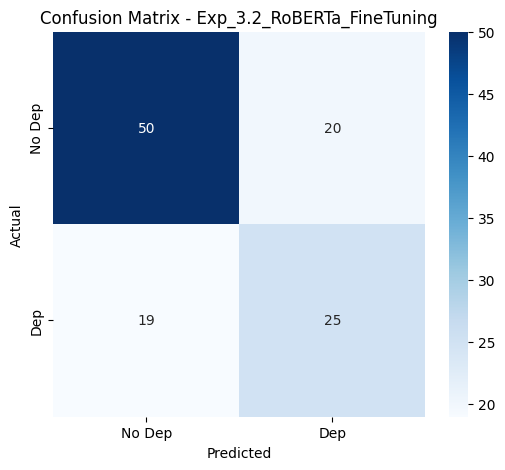

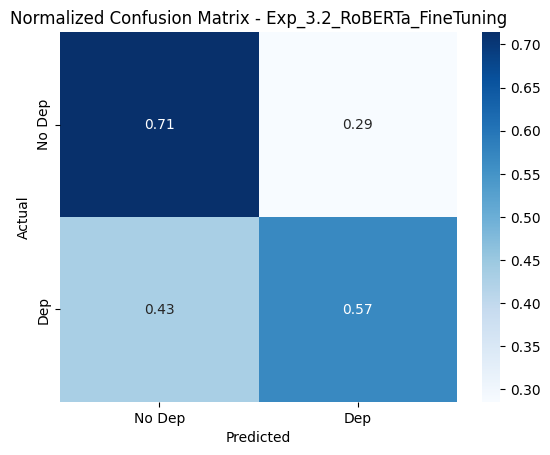


Modelo guardado en: /content/proyecto-transformacion-texto-imagen/models/Exp_3.2_RoBERTa_FineTuning.pkl
Métricas guardadas en: /content/proyecto-transformacion-texto-imagen/models/../results/Exp_3.2_RoBERTa_FineTuning_metrics.json


<Figure size 640x480 with 0 Axes>

In [17]:

# Extraer embeddings del modelo fine-tuneado para PKL
from transformers import AutoModelForSequenceClassification
CKPT_32 = f'{PROJECT_ROOT}/models/checkpoints/bertin-project_bertin-roberta-base-spanish/checkpoint-228'

# Guardar tokenizer en checkpoint
AutoTokenizer.from_pretrained(ROBERTA).save_pretrained(CKPT_32)

X_tr_32  = extraer_embeddings_finetuned(X_train_clean, CKPT_32)
X_val_32 = extraer_embeddings_finetuned(X_val_clean,   CKPT_32)
X_te_32  = extraer_embeddings_finetuned(X_test_clean,  CKPT_32)

_, _, metrics_32 = train_logistic(
    X_tr_32, y_train, X_val_32, y_val,
    X_te_32, y_test, 'Exp_3.2_RoBERTa_FineTuning', models_dir=models_dir)


In [20]:
# ── Exp 3.3: ROBERTA Fine-Tuning ───────────────────────────
print("="*55)
print("EXP 3.3: mDeBERTa Fine-Tuning + Softmax")
print("  Train → val.csv (EarlyStopping) | Eval final → test.csv")
print("="*55)

trainer_33 = run_finetuning(
    X_train_clean, y_train,   # ← train para aprender pesos
    X_val_clean,   y_val,     # ← val para EarlyStopping (NO test)
    model_name=MDEBERTA,
    models_dir=models_dir
)

EXP 3.3: ROBERTA Fine-Tuning + Softmax
  Train → val.csv (EarlyStopping) | Eval final → test.csv


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

{'loss': '0.6654', 'grad_norm': '4.937', 'learning_rate': '1.673e-05', 'epoch': '1'}
{'eval_loss': '0.6318', 'eval_accuracy': '0.6316', 'eval_precision_macro': '0.6481', 'eval_recall_macro': '0.5312', 'eval_f1_macro': '0.462', 'eval_runtime': '1.338', 'eval_samples_per_second': '85.21', 'eval_steps_per_second': '5.979', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.6351', 'grad_norm': '9.43', 'learning_rate': '1.339e-05', 'epoch': '2'}
{'eval_loss': '0.6565', 'eval_accuracy': '0.6491', 'eval_precision_macro': '0.6337', 'eval_recall_macro': '0.575', 'eval_f1_macro': '0.5569', 'eval_runtime': '0.98', 'eval_samples_per_second': '116.3', 'eval_steps_per_second': '8.163', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.5679', 'grad_norm': '16.05', 'learning_rate': '1.006e-05', 'epoch': '3'}
{'eval_loss': '0.6519', 'eval_accuracy': '0.6754', 'eval_precision_macro': '0.6653', 'eval_recall_macro': '0.6724', 'eval_f1_macro': '0.6662', 'eval_runtime': '1.008', 'eval_samples_per_second': '113.1', 'eval_steps_per_second': '7.938', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:

# Extraer embeddings del modelo fine-tuneado para PKL
from transformers import AutoModelForSequenceClassification
CKPT_33 = f'{PROJECT_ROOT}/models/checkpoints/bertin-project_bertin-roberta-base-spanish/checkpoint-228'

# Guardar tokenizer en checkpoint
AutoTokenizer.from_pretrained(MDEBERTA).save_pretrained(CKPT_33)

X_tr_33  = extraer_embeddings_finetuned(X_train_clean, CKPT_33)
X_val_33 = extraer_embeddings_finetuned(X_val_clean,   CKPT_33)
X_te_33  = extraer_embeddings_finetuned(X_test_clean,  CKPT_33)

_, _, metrics_33 = train_logistic(
    X_tr_33, y_train, X_val_33, y_val,
    X_te_33, y_test, 'Exp_3.3_mDeBERTa_FineTuning', models_dir=models_dir)


In [18]:
# ── Exp 3.4: XLM Fine-Tuning ───────────────────────────
print("="*55)
print("EXP 3.4: XLM Fine-Tuning + Softmax")
print("  Train → val.csv (EarlyStopping) | Eval final → test.csv")
print("="*55)

trainer_34 = run_finetuning(
    X_train_clean, y_train,   # ← train para aprender pesos
    X_val_clean,   y_val,     # ← val para EarlyStopping (NO test)
    model_name=XLM,
    models_dir=models_dir
)

EXP 3.3: mDeBERTa Fine-Tuning + Softmax
  Train → val.csv (EarlyStopping) | Eval final → test.csv


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

{'loss': '0.7024', 'grad_norm': '2.876', 'learning_rate': '1.673e-05', 'epoch': '1'}
{'eval_loss': '0.6772', 'eval_accuracy': '0.614', 'eval_precision_macro': '0.307', 'eval_recall_macro': '0.5', 'eval_f1_macro': '0.3804', 'eval_runtime': '1.057', 'eval_samples_per_second': '107.9', 'eval_steps_per_second': '7.57', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.6483', 'grad_norm': '13.2', 'learning_rate': '1.339e-05', 'epoch': '2'}
{'eval_loss': '0.6223', 'eval_accuracy': '0.6667', 'eval_precision_macro': '0.6514', 'eval_recall_macro': '0.6062', 'eval_f1_macro': '0.6018', 'eval_runtime': '1.001', 'eval_samples_per_second': '113.9', 'eval_steps_per_second': '7.992', 'epoch': '2'}


...

{'loss': '0.425', 'grad_norm': '21.67', 'learning_rate': '3.392e-06', 'epoch': '5'}
{'eval_loss': '0.685', 'eval_accuracy': '0.693', 'eval_precision_macro': '0.6785', 'eval_recall_macro': '0.6825', 'eval_f1_macro': '0.68', 'eval_runtime': '1.061', 'eval_samples_per_second': '107.4', 'eval_steps_per_second': '7.539', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.3661', 'grad_norm': '23.06', 'learning_rate': '5.848e-08', 'epoch': '6'}
{'eval_loss': '0.6996', 'eval_accuracy': '0.7018', 'eval_precision_macro': '0.6842', 'eval_recall_macro': '0.6727', 'eval_f1_macro': '0.6762', 'eval_runtime': '1.069', 'eval_samples_per_second': '106.7', 'eval_steps_per_second': '7.485', 'epoch': '6'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '567.6', 'train_samples_per_second': '9.598', 'train_steps_per_second': '0.602', 'train_loss': '0.5323', 'epoch': '6'}
{'eval_loss': '0.685', 'eval_accuracy': '0.693', 'eval_precision_macro': '0.6785', 'eval_recall_macro': '0.6825', 'eval_f1_macro': '0.68', 'eval_runtime': '1.022', 'eval_samples_per_second': '111.6', 'eval_steps_per_second': '7.831', 'epoch': '6'}

Final Evaluation Metrics:
{'eval_loss': 0.6849644184112549, 'eval_accuracy': 0.6929824561403509, 'eval_precision_macro': 0.678469355350905, 'eval_recall_macro': 0.6824675324675324, 'eval_f1_macro': 0.6799550814149354, 'eval_runtime': 1.0216, 'eval_samples_per_second': 111.585, 'eval_steps_per_second': 7.831, 'epoch': 6.0}


In [ ]:

# Extraer embeddings del modelo fine-tuneado para PKL
from transformers import AutoModelForSequenceClassification
CKPT_34 = f'{PROJECT_ROOT}/models/checkpoints/bertin-project_bertin-roberta-base-spanish/checkpoint-228'

# Guardar tokenizer en checkpoint
AutoTokenizer.from_pretrained(XLM).save_pretrained(CKPT_34)

X_tr_34  = extraer_embeddings_finetuned(X_train_clean, CKPT_34)
X_val_34 = extraer_embeddings_finetuned(X_val_clean,   CKPT_34)
X_te_34  = extraer_embeddings_finetuned(X_test_clean,  CKPT_34)

_, _, metrics_34 = train_logistic(
    X_tr_34, y_train, X_val_34, y_val,
    X_te_34, y_test, 'Exp_3.4_XLM_FineTuning', models_dir=models_dir)


In [ ]:
# ==========================================
# CELDA 7: Tabla comparativa final
# ==========================================
import json

# Recolectar todas las métricas
todos_metrics = [
    metrics_11, metrics_12,
    metrics_21, metrics_22,
    metrics_23, metrics_23,
    metrics_31, metrics_32,
    metrics_33, metrics_34,
]

# Ordenar por F1 test descendente
todos_metrics.sort(key=lambda x: x['f1_macro_test'], reverse=True)

print("\n" + "="*80)
print("📊 TABLA COMPARATIVA FINAL — TODOS LOS EXPERIMENTOS")
print("="*80)
print(f"{'Experimento':<40} {'F1-Val':>8} {'F1-Test':>8} {'Accuracy':>9}")
print("-"*80)

for m in todos_metrics:
    marker = " ← BASELINE" if m == todos_metrics[0] else ""
    print(f"{m['experiment']:<40} "
          f"{m.get('f1_macro_val', 0):>8.4f} "
          f"{m['f1_macro_test']:>8.4f} "
          f"{m['accuracy_test']:>9.4f}{marker}")

# Guardar tabla completa
tabla_path = f'{RESULTS_DIR}/tabla_comparativa_final.json'
with open(tabla_path, 'w') as f:
    json.dump(todos_metrics, f, indent=4, ensure_ascii=False)

print(f"\n✓ Tabla guardada en {tabla_path}")
print(f"\n🏆 BASELINE SELECCIONADO: {todos_metrics[0]['experiment']}")
print(f"   F1-Macro Test: {todos_metrics[0]['f1_macro_test']:.4f}")
